In [2]:
import os
import wandb

# ---------------------------------------------------------------------------
# Make sure the repo root is on the Python path so that the local `env`,
# `utils`, and `wrappers` packages can be imported regardless of where the
# script is launched from.
# ---------------------------------------------------------------------------
import gymnasium as gym
import numpy as np

import env  # noqa: F401  – registers "my-four-room-v0" as a side-effect
from morl_baselines.multi_policy.gpi_pd.gpi_pd import GPIPD
from utils.eval import eval_full_room_gpipd
from wrappers.combine_wrapper import CombineWrapper

In [3]:
"""Training loop for the Four-Room environment using GPI-PD.

GPI-PD (Generalized Policy Improvement with Prioritized Dynamics) is a
sample-efficient multi-objective RL algorithm that combines:
  - GPI  : at evaluation time, the agent picks the best action across all
            previously-learned weight-specific Q-functions.
  - PER  : prioritized experience replay to focus learning on surprising
            transitions.
  - Dyna : a learned probabilistic ensemble dynamics model that generates
            synthetic rollouts, greatly improving sample efficiency.

The four-room environment has a 4-dimensional reward vector:
  [blue_triangle, blue_circle, red_triangle, red_circle]
All rewards are +1 when the corresponding shape is collected, 0 otherwise.
"""

import sys
import os
import wandb

# ---------------------------------------------------------------------------
# Make sure the repo root is on the Python path so that the local `env`,
# `utils`, and `wrappers` packages can be imported regardless of where the
# script is launched from.
# ---------------------------------------------------------------------------
import gymnasium as gym
import numpy as np

import env  # noqa: F401  – registers "my-four-room-v0" as a side-effect
from morl_baselines.multi_policy.gpi_pd.gpi_pd import GPIPD
from utils.eval import eval_full_room_gpipd
from wrappers.combine_wrapper import CombineWrapper

# ---------------------------------------------------------------------------
# Hyperparameters – explained
# ---------------------------------------------------------------------------

# ── Training budget ─────────────────────────────────────────────────────────
TOTAL_TIMESTEPS = int(1e4)
# 100 000 environment steps is enough to see meaningful convergence on this
# small (5×5) grid while keeping wall-clock time reasonable (a few minutes
# on CPU).

# ── Episode length cap ───────────────────────────────────────────────────────
MAX_EPISODE_LENGTH = 8
# Without a cap the agent could wander indefinitely on episodes where the goal
# is never reached.  50 steps is ≈10× the Manhattan diameter of the grid, so
# any optimal or near-optimal policy will finish well within this budget.

# ── GPI-PD / Q-learning ─────────────────────────────────────────────────────
LEARNING_RATE = 3e-4
# Standard Adam learning rate; works well across a broad class of deep-RL
# problems.

GAMMA = 0.99
# Discount factor.  0.99 lets the agent plan several steps ahead, important
# for collecting shapes that may be far from the starting cell.

BATCH_SIZE = 256
# Larger batches than the default (128) help on this environment because the
# effective state space is small and the replay buffer fills quickly with
# redundant transitions; bigger batches reduce variance with little extra cost.

BUFFER_SIZE = int(5e4)
# 50 000 transitions is more than enough for a 5×5 grid; keeping it modest
# avoids the first few thousand steps being dominated by near-zero-priority
# samples from before the policy has learned anything useful.

GRADIENT_UPDATES = 10
# Number of gradient steps taken per environment step once learning starts.
# The default (20) is appropriate for harder environments; 10 is sufficient
# here and halves training time.

LEARNING_STARTS = 500
# Collect 500 random transitions before the first gradient update so that the
# replay buffer already contains some diversity.

NET_ARCH = [64, 64]
# Two hidden layers of 64 units each.  The observation is only 2+8 = 10
# dimensional (position + collected-shape binary vector), so a smaller
# network than the default (4×256) converges faster and is less prone to
# overfitting.

TARGET_NET_UPDATE_FREQ = 500
# Hard-copy the online Q-network to the target network every 500 steps.
# This stabilises training while still providing reasonably fresh targets.

# ── Exploration ──────────────────────────────────────────────────────────────
INITIAL_EPSILON = 0.3
# Start with 30 % random exploration so the agent visits different rooms
# before the policy solidifies.

FINAL_EPSILON = 0.05
# Keep 5 % random exploration throughout training to avoid getting stuck in
# local optima (the grid has multiple shapes, so greedy behaviour can miss
# entire rooms).

EPSILON_DECAY_STEPS = int(5e4)
# Linearly anneal epsilon over the first half of training.

# ── Dyna (model-based rollouts) ───────────────────────────────────────────────
DYNA = False
# Enable the learned dynamics model; it is the primary source of sample
# efficiency in GPI-PD.

DYNAMICS_ROLLOUT_STARTS = 2000
# Wait until 2 000 real transitions have been collected before starting model
# rollouts so that the ensemble has enough data to produce useful predictions.

DYNAMICS_ROLLOUT_FREQ = 250
# Generate new synthetic transitions every 250 environment steps.

DYNAMICS_ROLLOUT_LEN = 1
# One-step rollouts are sufficient for this simple environment and avoid
# compounding model errors over long imagined trajectories.

DYNAMICS_ROLLOUT_BATCH_SIZE = 10000
# Number of synthetic transitions to generate per rollout phase.  Together
# with a real_ratio of 0.5, half of every training batch will be synthetic,
# which roughly doubles the effective sample size.

DYNAMICS_NET_ARCH = [64, 64, 64]
# Smaller ensemble network than the default (3×256) because the transition
# dynamics of the four-room grid are deterministic and low-dimensional.

DYNAMICS_ENSEMBLE_SIZE = 5
# Five ensemble members provide good uncertainty estimates while staying fast.

DYNAMICS_NUM_ELITES = 2
# Use the two best ensemble members for rollouts (standard practice).

REAL_RATIO = 0.5
# 50 % real / 50 % synthetic transitions in each training batch.

# ── Prioritized Experience Replay (PER) ─────────────────────────────────────
PER = True
# Enable PER so that surprising (high-TD-error) transitions are replayed more
# often.  Particularly useful in sparse-reward settings like this one where
# most transitions carry zero reward.

ALPHA_PER = 0.6
# PER exponent: 0 = uniform sampling, 1 = fully prioritised.
# 0.6 is the canonical value from the original PER paper.

# ── Multi-objective / GPI ────────────────────────────────────────────────────
USE_GPI = True
# Enable Generalised Policy Improvement so the agent can leverage all
# previously learned weight-specific Q-functions at decision time.

GPI_PD = True
# Enable the GPI-PD priority update, which re-scores transitions according to
# the GPI improvement signal rather than per-policy TD error alone.

# ── Training / evaluation schedule ──────────────────────────────────────────
TIMESTEPS_PER_ITER = 10000
# Each outer iteration trains for 10 000 steps then picks a new weight vector.
# With TOTAL_TIMESTEPS = 1e5 this gives 10 outer iterations.

EVAL_FREQ = 2000
# Evaluate the current policy every 2 000 steps (logged to W&B).

EVAL_MO_FREQ = 10000
# Run the full multi-objective evaluation (hypervolume, EUM, etc.) every
# 10 000 steps – once per outer iteration.

NUM_EVAL_WEIGHTS_FOR_FRONT = 100
# Sample 100 uniformly-spaced weight vectors to approximate the Pareto front
# at evaluation time.

NUM_EVAL_EPISODES_FOR_FRONT = 5
# Run 5 episodes per weight vector during evaluation.  This is enough to
# average out stochastic starting positions in the four-room grid.

# ── Reference point (hypervolume lower bound) ────────────────────────────────
REF_POINT = np.array([0.0, 0.0])

# ── Logging ──────────────────────────────────────────────────────────────────
LOG = True
# Log training metrics to Weights & Biases.  Set to False for a quick local
# test run without a W&B account.

EXPERIMENT_NAME = "GPI-PD"
PROJECT_NAME = "MORL-Baselines"
SEED = 42

In [4]:
train_env = CombineWrapper(gym.wrappers.TimeLimit(
    gym.make("my-four-room-v0"),
    max_episode_steps=MAX_EPISODE_LENGTH,
), [1, 0])

eval_env = CombineWrapper(gym.wrappers.TimeLimit(
    gym.make("my-four-room-v0"),
    max_episode_steps=MAX_EPISODE_LENGTH,
), [1, 0])

agent = GPIPD(
    env=train_env,
    # Q-learning
    learning_rate=LEARNING_RATE,
    gamma=GAMMA,
    batch_size=BATCH_SIZE,
    buffer_size=BUFFER_SIZE,
    gradient_updates=GRADIENT_UPDATES,
    learning_starts=LEARNING_STARTS,
    net_arch=NET_ARCH,
    target_net_update_freq=TARGET_NET_UPDATE_FREQ,
    # Exploration
    initial_epsilon=INITIAL_EPSILON,
    final_epsilon=FINAL_EPSILON,
    epsilon_decay_steps=EPSILON_DECAY_STEPS,
    # Dyna
    dyna=DYNA,
    dynamics_rollout_starts=DYNAMICS_ROLLOUT_STARTS,
    dynamics_rollout_freq=DYNAMICS_ROLLOUT_FREQ,
    dynamics_rollout_len=DYNAMICS_ROLLOUT_LEN,
    dynamics_rollout_batch_size=DYNAMICS_ROLLOUT_BATCH_SIZE,
    dynamics_net_arch=DYNAMICS_NET_ARCH,
    dynamics_ensemble_size=DYNAMICS_ENSEMBLE_SIZE,
    dynamics_num_elites=DYNAMICS_NUM_ELITES,
    real_ratio=REAL_RATIO,
    # PER
    per=PER,
    alpha_per=ALPHA_PER,
    # Multi-objective / GPI
    use_gpi=USE_GPI,
    gpi_pd=GPI_PD,
    # Logging / misc
    log=LOG,
    experiment_name=EXPERIMENT_NAME,
    project_name=PROJECT_NAME,
    seed=SEED,
)
# agent.load(path="weights/GPI-PD.tar")

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: kristofs (kristofs-ai) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [6]:
agent.load("weights/gpipd_four_room_0.0_1.0_kxr77lc4.tar")

wandb: ERROR Unable to save notebook session history.


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:245: UserWarning: WARN: The reward returned by `step()` must be a float, int, np.integer or np.floating, actual type: <class 'numpy.ndarray'>
  logger.warn(


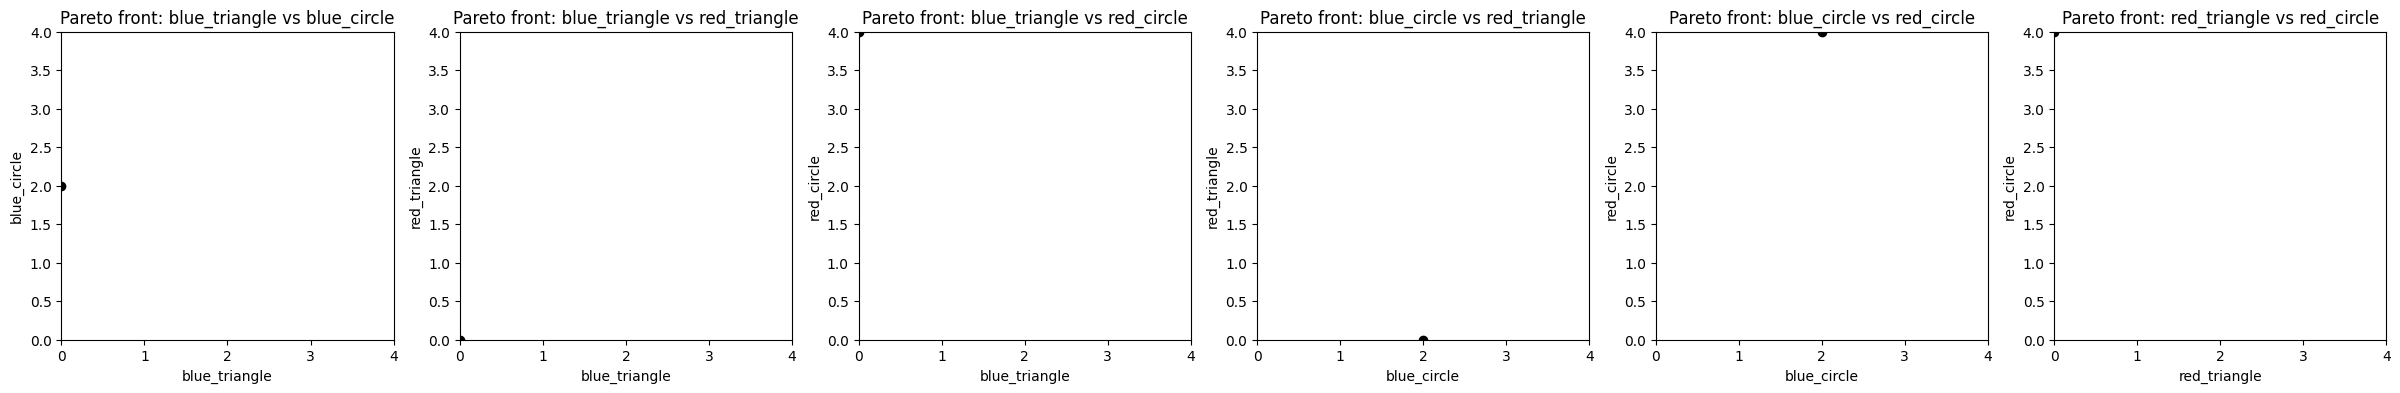

In [7]:
with wandb.init(project="MORL-Baselines", reinit=True, id="kxr77lc4"):
    eval_full_room_gpipd(agent, n_weights=25, n_episodes_per_weight=5, render=False)